In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [51]:
def f(m,k):
    return 1 - (1+k/(0.5-2*k))*np.exp(-2*k*m*8) + k/(0.5-2*k)*np.exp(-0.5*m*8)

In [22]:
kappa_sub = 0.115023
m0m = 0.055926356407297
kappa_range = np.linspace(kappa_sub-8e-5, kappa_sub-1e-2, 10)

In [5]:
M = []
num_ensambles = 3000
N = 1000000
for kappa in kappa_range:
    mags = np.empty(num_ensambles)
    for n in range(num_ensambles):
        with open('results/{0}_{1}_fig6_rho_sub_critical.p'.format(n, kappa), "rb") as f:
            mag = pickle.load(f)
            mags[n] = mag
    M.append(mags)

In [23]:
cutoff = 0.25
md = []
for mags in M:
    mag = m0m - np.mean(mags[mags < cutoff])
    md.append(mag)

In [91]:
rho = 2e-3
teor = []
kappa_range_2 = np.linspace(kappa_sub-1e-2, kappa_sub-8e-6, 1000)
for i, kappa in enumerate(kappa_range_2):
    minit = 0.0515
    for j in range(1000):
        minit = rho + (1-rho)*f(minit, kappa)
    teor.append(m0m-minit)

In [42]:
z = np.polyfit(np.log(-kappa_range[1:-2]+kappa_sub), np.log(md[1:-2]), 1)
print(z)
p = np.poly1d(z)

[ 0.28748449 -1.79182072]


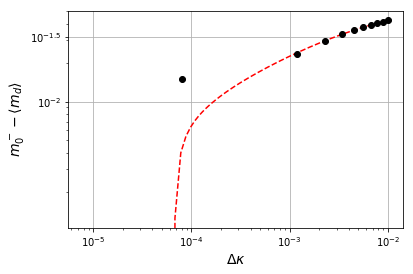

In [92]:
plt.loglog(-kappa_range_2+kappa_sub, teor, 'r--')
plt.loglog(-kappa_range+kappa_sub, md, 'ko')
plt.yticks([1e-2, 10**(-1.5)], ["$10^{-2}$", "$10^{-1.5}$"])
plt.grid()
plt.xlabel(r"$\Delta\kappa$", fontsize=14)
plt.ylabel(r"$m_0^-- \langle m_d\rangle$", fontsize=14)
plt.show()
#plt.loglog(-kappa_range+kappa_sub, np.exp(p(np.log(-kappa_range+kappa_sub))), 'k-')


In [94]:
Nnu = 656
kappa_range = (np.linspace(-1, 1, 20))**3
max_new = 0.108021+10/Nnu
min_new = 0.108021-10/Nnu
kappa_range = (kappa_range-kappa_range.min()) * (max_new - min_new) / 2 + min_new

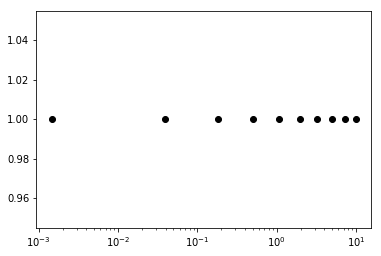

In [100]:
plt.semilogx(-(kappa_range-kc)*Nnu, [1]*20, 'ko')

In [101]:
kappa_range

array([0.0927771 , 0.09710202, 0.10052017, 0.10313824, 0.1050629 ,
       0.10640082, 0.10725869, 0.10774319, 0.10796099, 0.10801878,
       0.10802322, 0.10808101, 0.10829881, 0.10878331, 0.10964118,
       0.1109791 , 0.11290376, 0.11552183, 0.11893998, 0.1232649 ])